<a href="https://colab.research.google.com/github/Rutuja-kshirsagar1/gen-ai-assignments/blob/main/gen_ai_assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time

print('TensorFlow version:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: (70000, 28, 28, 1)


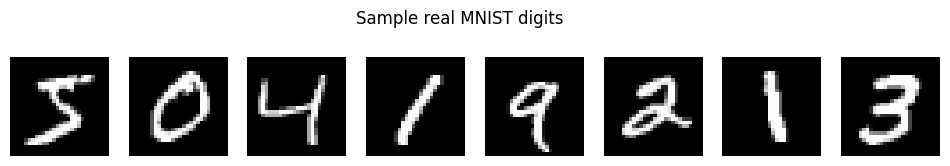

In [2]:
(x_train, y_train), (x_test, _) = keras.datasets.mnist.load_data()
x_train = np.concatenate([x_train, x_test], axis=0).astype('float32')
x_train = x_train.reshape(-1, 28, 28, 1)

x_train_vae = x_train / 255.0

x_train_gan = (x_train - 127.5) / 127.5

print('Dataset shape:', x_train.shape)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('Sample real MNIST digits')
plt.show()

In [3]:
LATENT_DIM = 16
BATCH_SIZE = 128
VAE_EPOCHS = 20
class Sampling(layers.Layer):
    """Reparameterization trick: z = mean + std * epsilon"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- Encoder ---
encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      2,064 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 16)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 424,480 (1.62 MB)

 Trainable params: 424,480 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# --- Decoder ---
latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,993 (425.75 KB)

 Trainable params: 108,993 (425.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))


In [6]:
vae_history = vae.fit(x_train_vae, epochs=VAE_EPOCHS, batch_size=BATCH_SIZE, verbose=1)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - kl_loss: 11.3325 - loss: 178.1947 - recon_loss: 166.8622
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 111s 203ms/step - kl_loss: 21.1196 - loss: 113.5572 - recon_loss: 92.4377
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - kl_loss: 22.1414 - loss: 106.8265 - recon_loss: 84.6851
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 140s 200ms/step - kl_loss: 22.4045 - loss: 104.4306 - recon_loss: 82.0261
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 110s 201ms/step - kl_loss: 22.5439 - loss: 103.0384 - recon_loss: 80.4945
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - kl_loss: 22.6437 - loss: 102.1039 - recon_loss: 79.4601
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 110s 200ms/step - kl_loss: 22.6946 - loss: 101.3352 - recon_loss: 78.6407
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 109s 200ms/step - kl_loss: 22.7083 - loss: 100.7334 - recon_loss: 78.0251
Epoch 9/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - kl_loss: 22.7010 - loss: 100.

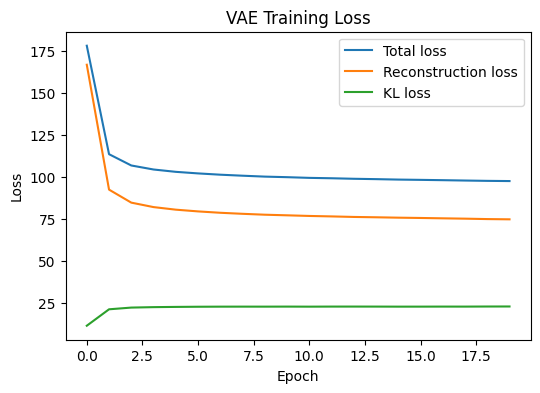

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(vae_history.history['loss'], label='Total loss')
plt.plot(vae_history.history['recon_loss'], label='Reconstruction loss')
plt.plot(vae_history.history['kl_loss'], label='KL loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('VAE Training Loss')
plt.legend(); plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


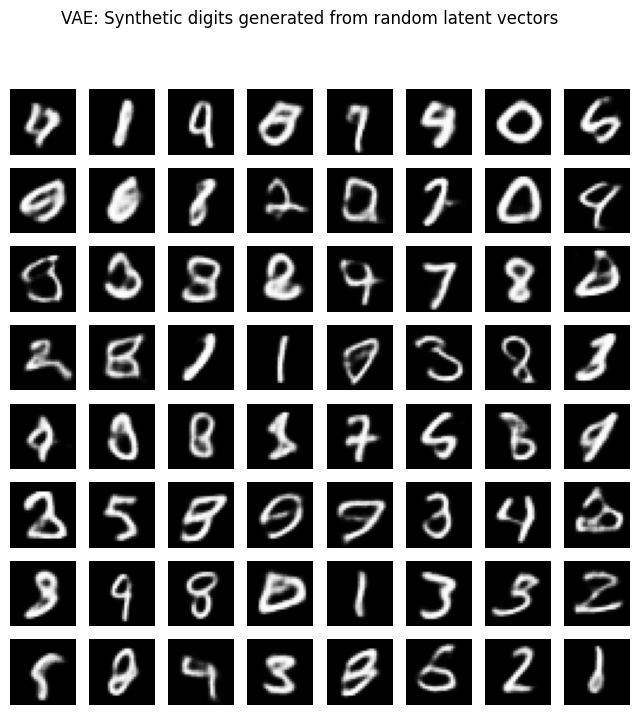

In [8]:
n = 8
random_latent_vectors = np.random.normal(size=(n * n, LATENT_DIM))
generated_images = decoder.predict(random_latent_vectors)

fig, axes = plt.subplots(n, n, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('VAE: Synthetic digits generated from random latent vectors')
plt.show()

In [9]:
NOISE_DIM = 100
GAN_EPOCHS = 40  # more epochs = sharper digits; increase if you have GPU time

train_dataset = tf.data.Dataset.from_tensor_slices(x_train_gan).shuffle(70000).batch(BATCH_SIZE, drop_remainder=True)

def make_generator():
    model = keras.Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((7, 7, 128)),
        layers.Conv2DTranspose(64, 5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(32, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(1, 5, strides=2, padding='same', use_bias=False, activation='tanh'),
    ], name='generator')
    return model

def make_discriminator():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1),
    ], name='discriminator')
    return model

generator = make_generator()
discriminator = make_discriminator()
generator.summary()
discriminator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 7, 7, 64)       │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,472 (3.47 MB)

 Trainable params: 896,736 (3.42 MB)

 Non-trainable params: 12,736 (49.75 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)  # label smoothing
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))
    return gen_loss, disc_loss

In [ ]:
seed = tf.random.normal([64, NOISE_DIM])
gan_history = {'gen_loss': [], 'disc_loss': []}

for epoch in range(GAN_EPOCHS):
    start = time.time()
    gl_list, dl_list = [], []
    for image_batch in train_dataset:
        gl, dl = train_step(image_batch)
        gl_list.append(float(gl))
        dl_list.append(float(dl))
    gan_history['gen_loss'].append(np.mean(gl_list))
    gan_history['disc_loss'].append(np.mean(dl_list))
    print(f'Epoch {epoch+1}/{GAN_EPOCHS} - gen_loss: {gan_history["gen_loss"][-1]:.3f} '
          f'disc_loss: {gan_history["disc_loss"][-1]:.3f} ({time.time()-start:.1f}s)')

    if (epoch + 1) % 10 == 0 or epoch == 0:
        gen_imgs = (generator(seed, training=False).numpy() + 1) / 2.0
        fig, axes = plt.subplots(4, 8, figsize=(10, 5))
        for i, ax in enumerate(axes.flat):
            ax.imshow(gen_imgs[i, :, :, 0], cmap='gray')
            ax.axis('off')
        plt.suptitle(f'GAN generated digits — epoch {epoch+1}')
        plt.show()

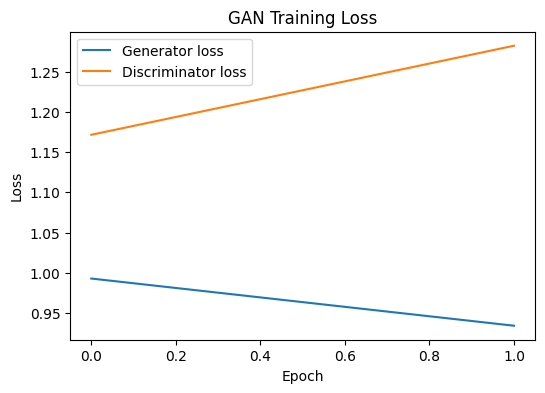

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(gan_history['gen_loss'], label='Generator loss')
plt.plot(gan_history['disc_loss'], label='Discriminator loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('GAN Training Loss')
plt.legend(); plt.show()

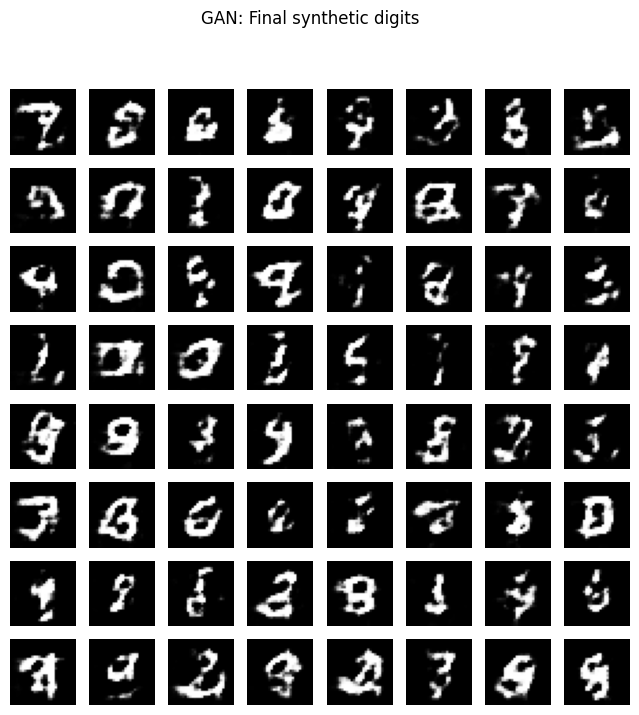

In [13]:
noise = tf.random.normal([64, NOISE_DIM])
gen_imgs = (generator(noise, training=False).numpy() + 1) / 2.0

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(gen_imgs[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('GAN: Final synthetic digits')
plt.show()
